# Physics-Informed Neural Network (PINN) for SIR Model

This model solves the forward problem for the system of ODEs provided:
* **S**: Susceptible
* **I**: Infected
* **R**: Recovered

The model is defined by the following system of first-order ordinary differential equations:

$$
\begin{aligned}
\frac{dS}{dt} &= -\beta S(t) I(t) \\
\frac{dI}{dt} &= \beta S(t) I(t) - \gamma I(t) \\
\frac{dR}{dt} &= \gamma I(t)
\end{aligned}
$$



### Parameters and Initial Conditions

Given the constants and the state of the population at $t = 0$:

**Parameters:**
* $\beta = 0.3$
* $\gamma = 0.1$

**Initial Conditions:**
* $S(0) = 0.99$
* $I(0) = 0.01$
* $R(0) = 0$


In [1]:
import jax
import jax.numpy as jnp
from jax import grad, vmap
import optax
import matplotlib.pyplot as plt

In [2]:
class FCN:
    @staticmethod
    def init_parameters(key, layer_sizes):
        keys = jax.random.split(key, len(layer_sizes)-1)
        parameters = [FCN._random_layer_parameters(k, m, n)
                      for k, m, n in zip(keys, layer_sizes[:-1], layer_sizes[1:])]
        return parameters

    @staticmethod
    def _random_layer_parameters(key, m, n):
        W_key, b_key = jax.random.split(key)
        v = jnp.sqrt(1/m)
        W = jax.random.uniform(W_key, (n, m), minval=-v, maxval=v)
        b = jax.random.uniform(b_key, (n,), minval=-v, maxval=v)
        return W, b

    @staticmethod
    def forward(parameters, x):
        activation_fn = jnp.tanh
        for W, b in parameters[:-1]:
            x = activation_fn(jnp.dot(W, x) + b)
        W_last, b_last = parameters[-1]
        y = jnp.dot(W_last, x) + b_last
        return y

In [3]:
def PINN_physics_loss(parameters, t, network):

    sir = network.forward(parameters, t)
    s = sir[0]
    i = sir[1]
    r = sir[2]

    ds_dt = jax.grad(lambda tt: network.forward(parameters, tt)[0])(t)
    di_dt = jax.grad(lambda tt: network.forward(parameters, tt)[1])(t)
    dr_dt = jax.grad(lambda tt: network.forward(parameters, tt)[1])(t)

    r1 = ds_dt + (0.3 * s * i)
    r2 = di_dt - (0.3 * s * i) + (0.1 * i)
    r3 = dr_dt - (0.1 * i)

    return r1**2 + r2**2 + r3**2


def PINN_boundary_losses(parameters, x_boundary, network):

    sir0 = network.forward(parameters, x_boundary)

    loss_s0 = (sir0[0] - 0.99) ** 2
    loss_i0 = (sir0[1] - 0.01) ** 2
    loss_r0 = (sir0[2]) ** 2

    return loss_s0, loss_i0, loss_r0


def PINN_loss_batch(parameters, x_boundary, x_physics_batch, network):

    loss_physics_batch = jax.vmap(PINN_physics_loss, in_axes=(None, 0, None))(parameters, x_physics_batch, network)
    loss_physics = jnp.mean(loss_physics_batch)
    loss_s0, loss_i0, loss_r0 = PINN_boundary_losses(parameters, x_boundary, network)

    return 1e-3 * loss_physics + (loss_s0 + loss_i0 + loss_r0)


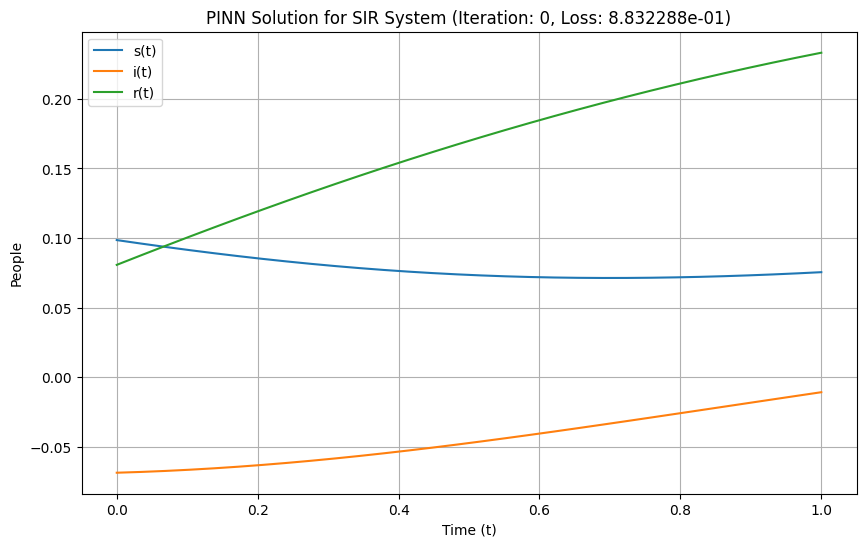

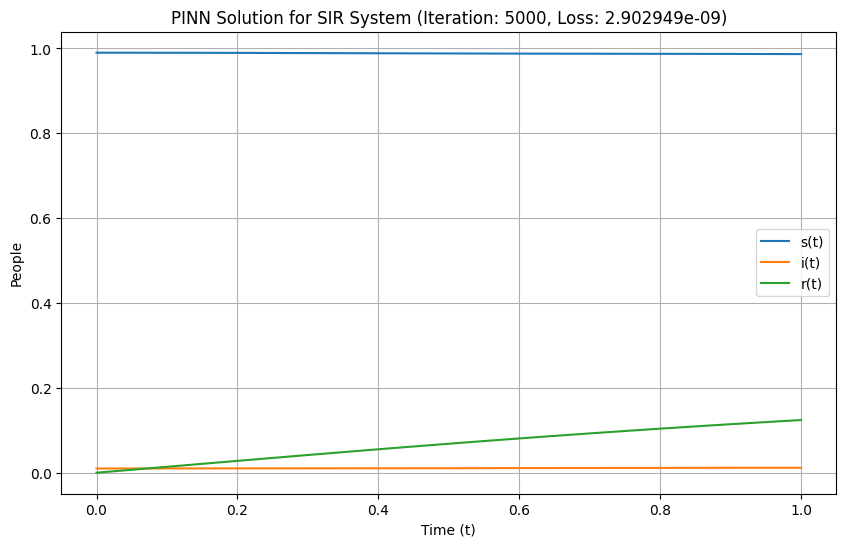

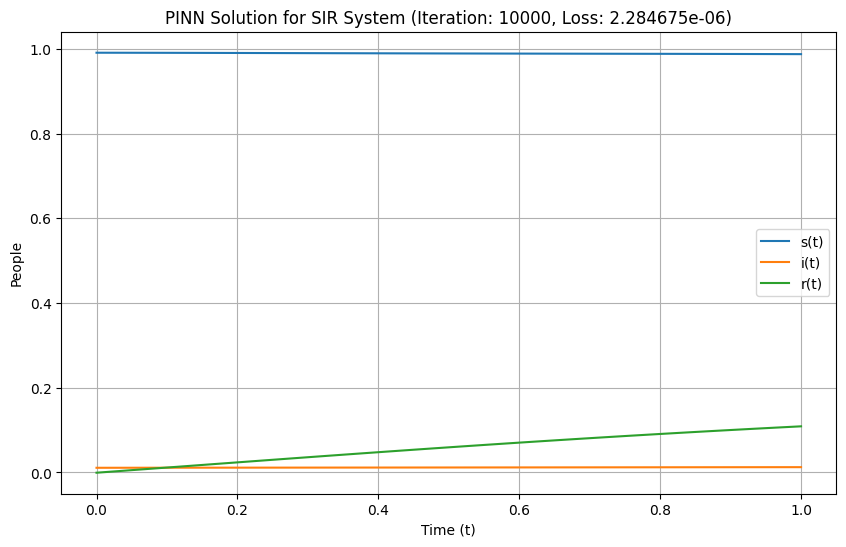

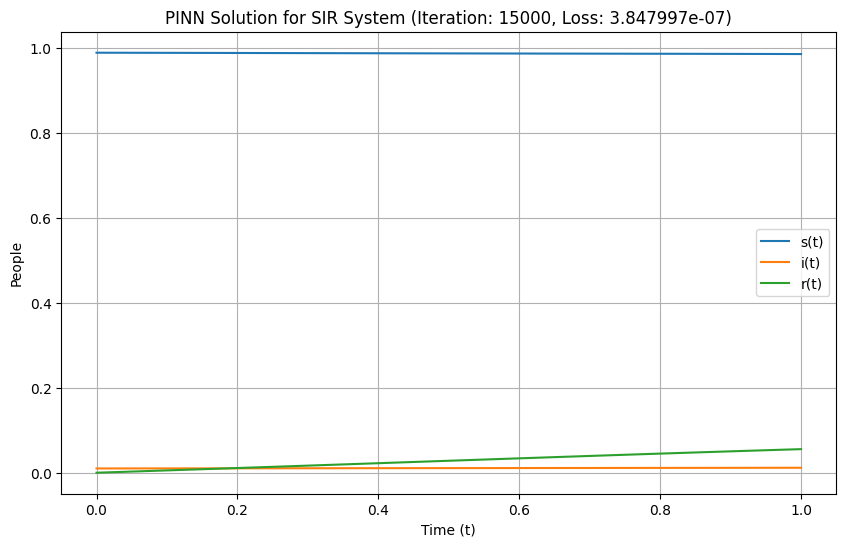

Forward PINN training loop finished in 9.84 seconds


In [4]:
import time # Import time module
from functools import partial

@partial(jax.jit, static_argnums=(1, 5))
def PINN_step(opt_state, optimiser, parameters, x_boundary, x_physics_batch, network):

    loss, grads = jax.value_and_grad(PINN_loss_batch, argnums=0)(
        parameters, x_boundary, x_physics_batch, network
    )

    updates, opt_state = optimiser.update(grads, opt_state, parameters)
    parameters = optax.apply_updates(parameters, updates)

    return loss, opt_state, parameters

x_boundary = jnp.array([0.0])
x_physics_batch = jnp.linspace(0, 1, 30).reshape(-1, 1)
x_test_batch = jnp.linspace(0, 1, 30).reshape(-1, 1)

network = FCN

# Initialize a JAX random key
key = jax.random.PRNGKey(0)
parameters = network.init_parameters(key, [1, 32, 32, 3])

# Initialize the optimizer and its state
optimiser = optax.adam(learning_rate=1e-3)
opt_state = optimiser.init(parameters)

start_time_forward = time.time() # Record start time
for i in range(15001):
    loss, opt_state, parameters = PINN_step(
        opt_state,optimiser,parameters,x_boundary,x_physics_batch,network)

    if i % 5000 == 0:
        sir_test_batch = jax.vmap(network.forward, in_axes=(None, 0))(parameters, x_test_batch)

        plt.figure(figsize=(10, 6))
        plt.plot(x_test_batch, sir_test_batch[:, 0], label='s(t)')
        plt.plot(x_test_batch, sir_test_batch[:, 1], label='i(t)')
        plt.plot(x_test_batch, sir_test_batch[:, 2], label='r(t)')
        plt.xlabel('Time (t)')
        plt.ylabel('People')
        plt.title(f'PINN Solution for SIR System (Iteration: {i}, Loss: {loss:.6e})')
        plt.legend()
        plt.grid(True)
        plt.show()

end_time_forward = time.time() # Record end time
print(f"Forward PINN training loop finished in {end_time_forward - start_time_forward:.2f} seconds")

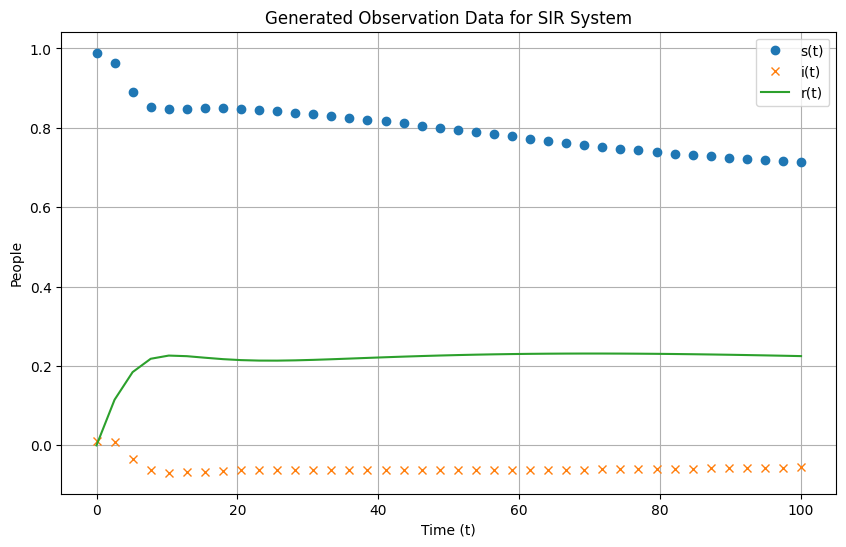

In [5]:
# Generate obs data using forward pinn

t_obs = jnp.linspace(0, 1, 20).reshape(-1, 1)
sir_obs = jax.vmap(network.forward, in_axes=(None, 0))(parameters, t_obs)

# Plot the generated observation data
plt.figure(figsize=(10, 6))
plt.plot(t_obs, sir_obs[:, 0], 'o', label='s(t)')
plt.plot(t_obs, sir_obs[:, 1], 'x', label='i(t)')
plt.plot(t_obs, sir_obs[:, 2], '-', label='r(t)')
plt.xlabel('Time (t)')
plt.ylabel('People')
plt.title('Generated Observation Data for SIR System')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
def PINN_inverse_physics_loss(parameters, theta, t, network):

    sir = network.forward(parameters, t)
    s = sir[0]
    i = sir[1]
    r = sir[2]

    beta = theta[0]
    gamma = theta[1]

    ds_dt = jax.grad(lambda tt: network.forward(parameters, tt)[0])(t)
    di_dt = jax.grad(lambda tt: network.forward(parameters, tt)[1])(t)
    dr_dt = jax.grad(lambda tt: network.forward(parameters, tt)[1])(t)


    r1 = ds_dt + (0.3 * s * i)
    r2 = di_dt - (0.3 * s * i) + (0.1 * i)
    r3 = dr_dt - (0.1 * i)

    return r1**2 + r2**2 + r3**2

def PINN_inverse_loss_batch(parameters, theta, x_physics_batch, network):

    physics_losses = jax.vmap(PINN_inverse_physics_loss, in_axes=(None, None, 0, None))(parameters, theta, x_physics_batch, network)
    loss_physics = jnp.mean(physics_losses)

    sir_pred = jax.vmap(network.forward, in_axes=(None, 0))(parameters, t_obs)
    loss_data = jnp.mean((sir_pred - sir_obs)**2)

    return loss_physics + 100*loss_data


In [7]:
# JIT-compiled Step Function
@partial(jax.jit, static_argnums=(1, 5))
def inverse_step(opt_state, optimiser, parameters, theta, x_physics_batch, network):

    # get loss and gradient over the combined parameters (network weights + alpha)
    loss, grads = jax.value_and_grad(PINN_inverse_loss_batch, argnums=(0, 1))(parameters, theta, x_physics_batch, network)
    grads_params, grads_theta = grads

    # apply parameter update
    updates, opt_state = optimiser.update((grads_params, grads_theta), opt_state,(parameters, theta))
    parameters, theta = optax.apply_updates((parameters, theta), updates)

    return loss, opt_state, parameters, theta

In [8]:
# Initialize and Run Training
parameters_inv = network.init_parameters(key, [1, 32, 32, 3])
theta_inv = jnp.array([0.5, 0.5])

optimiser_inv = optax.adam(1e-3)
opt_state_inv = optimiser_inv.init((parameters_inv, theta_inv))

x_physics_batch = jnp.linspace(0, 100, 250).reshape(-1, 1)

iter: 0 loss: 20.520075 beta: 0.5 gamma: 0.5


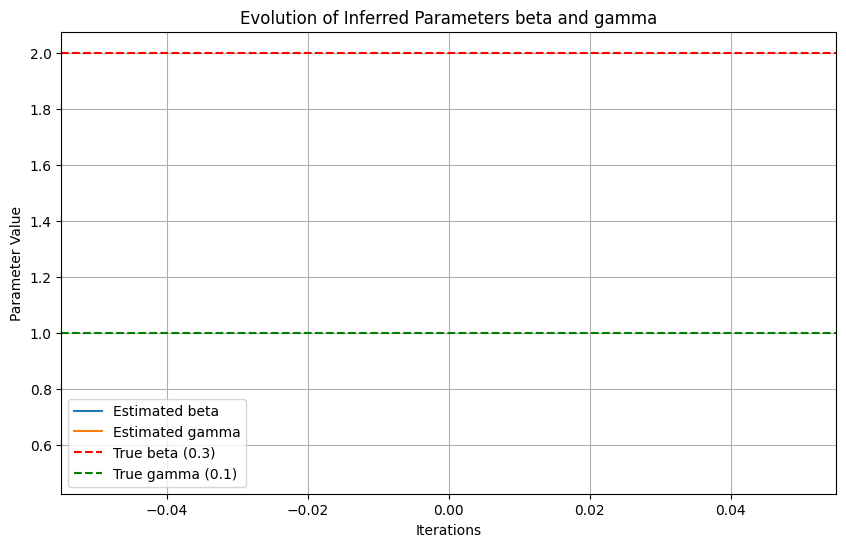

iter: 3000 loss: 0.000594387 beta: 0.5 gamma: 0.5


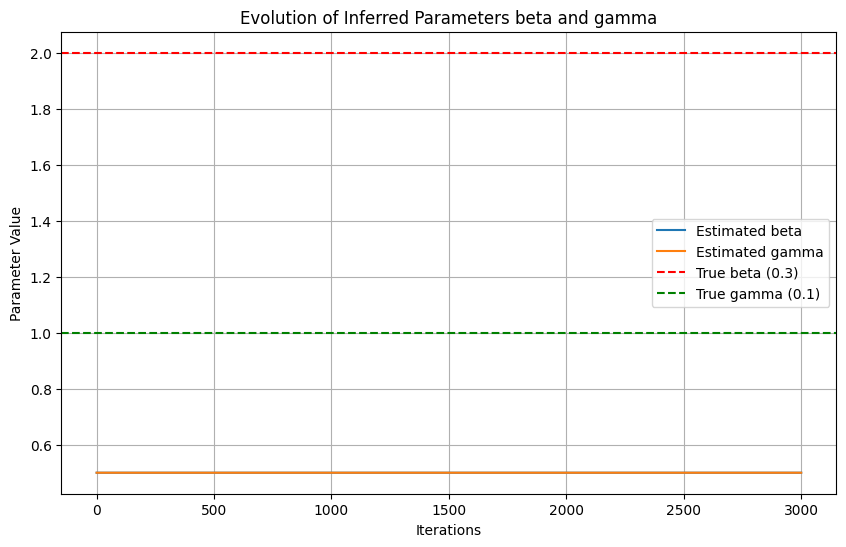

iter: 6000 loss: 0.00043858038 beta: 0.5 gamma: 0.5


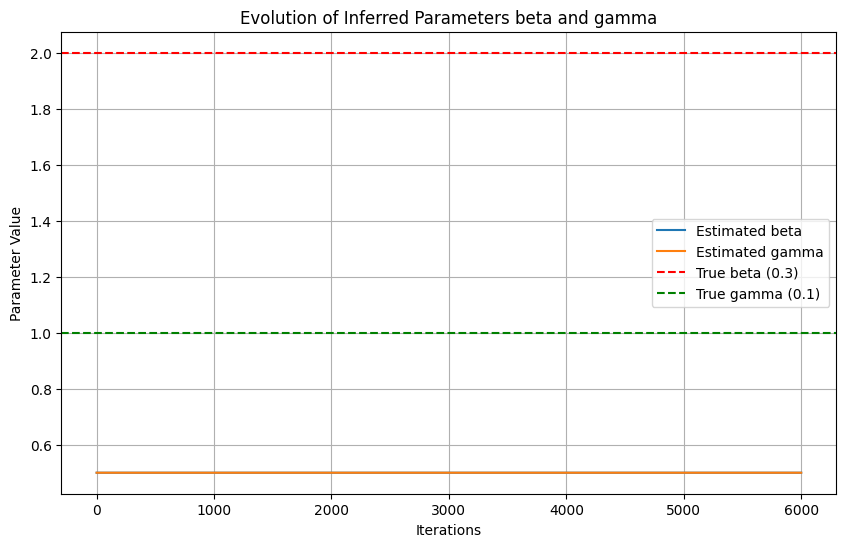

Inverse PINN training loop finished in 9.45 seconds


In [9]:
# Training loop

# Initialize lists to store values for plotting
iters_to_plot = []
beta_values = []
gamma_values = []

start_time_inverse = time.time() # Record start time
for i in range(6001):

    loss, opt_state_inv, parameters_inv, theta_inv = inverse_step(
        opt_state_inv, optimiser_inv, parameters_inv, theta_inv, x_physics_batch, network)

    # Store values for plotting in every iteration
    iters_to_plot.append(i)
    beta_values.append(theta_inv[0])
    gamma_values.append(theta_inv[1])

    if i % 3000 == 0:
        print("iter:", i, "loss:", loss,"beta:", theta_inv[0],"gamma:", theta_inv[1])

        # Plot a and b values (using all stored values up to this point)
        plt.figure(figsize=(10, 6))
        plt.plot(iters_to_plot, beta_values, label='Estimated beta')
        plt.plot(iters_to_plot, gamma_values, label='Estimated gamma')
        plt.xlabel('Iterations')
        plt.ylabel('Parameter Value')
        plt.title('Evolution of Inferred Parameters beta and gamma')
        plt.axhline(y=2.0, color='r', linestyle='--', label='True beta (0.3)')
        plt.axhline(y=1.0, color='g', linestyle='--', label='True gamma (0.1)')
        plt.legend()
        plt.grid(True)
        plt.show()

end_time_inverse = time.time() # Record end time
print(f"Inverse PINN training loop finished in {end_time_inverse - start_time_inverse:.2f} seconds")